In [66]:
import pandas as pd
import os
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import h5py

from utils import *

In [ ]:
config = yaml.safe_load(open('/Users/ursic/PhD/Projects/1_DataAnalysis_zebrafish/beads_in_zebrafish/magnetic_tweezers_SD/config.yml'))

filepath_measurements_info = config['filepath_measurements_info']
dir_plots = os.path.join(config['dir_parent'], '3_plots')  # Folder for saving plots
dir_analysis = os.path.join(config['dir_parent'], '2_analysis')  # Folder for saving analysis results
recalculate = config['recalculate']  # Whether to recalculate measurements if they already exist
pix_size = config['pix_size'] 
dt = config['dt']  # Time step in seconds\

force_ranges = [(30,60)]

subtract_backgroung = config['subtract_backgroung']  # Whether to subtract background from displacement

creep_only = False
if config['fit_type'] == 'creep jeff':
    creep_only = True  # If the fit type is 'creep jeff', we only plot creep curves
    
creep_only_label = '_only_creep' if creep_only else ''

displacement_column = 'CORRECTED DISPLACEMENT [um]' if subtract_backgroung else 'DISPLACEMENT [um]'  # Use the original displacement, not corrected

subtr_bck_label = 'subtr_bck' if subtract_backgroung else 'no_subtr_bck'

In [68]:
folder = '/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/2_analysis/measurements_extended_info/'

df_all_tracks = pd.DataFrame()
for file in os.listdir(folder):
    if file.endswith('.h5'):
        # Read the data using pandas
        df = pd.read_hdf(folder+file)
        df['file'] = file
        df['EXPERIMENT'] = file[:18].replace('_', '')
        df['EMBRYO'] = file[:15].replace('_', '')
        df_all_tracks = pd.concat([df_all_tracks, df])

df_all_tracks.dropna(subset=[displacement_column], inplace=True)

print(df_all_tracks.columns)

Index(['LABEL', 'ID', 'TRACK_ID', 'QUALITY', 'POSITION_X', 'POSITION_Y',
       'POSITION_Z', 'POSITION_T', 'FRAME', 'RADIUS', 'VISIBILITY',
       'MANUAL_SPOT_COLOR', 'MEAN_INTENSITY_CH1', 'MEDIAN_INTENSITY_CH1',
       'MIN_INTENSITY_CH1', 'MAX_INTENSITY_CH1', 'TOTAL_INTENSITY_CH1',
       'STD_INTENSITY_CH1', 'CONTRAST_CH1', 'SNR_CH1', 'DISTANCE [um]',
       'MAGNET_STATUS', 'PULSE_NUMBER', 'FORCE [pN]', 'MT_STATUS',
       'DISPLACEMENT [um]', 'CORRECTION_k', 'CORRECTION_k_ERR', 'CORRECTION_N',
       'CORRECTION_N_ERR', 'CORRECTED DISPLACEMENT [um]', 'file', 'EXPERIMENT',
       'EMBRYO'],
      dtype='object')


In [69]:
# load data
df_results_all = pd.read_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_material_properies_{subtr_bck_label}.csv')
df_results_all.sort_values(by='MT_STATUS', ascending=False, inplace=True)

r_sq_min = 0.5
# filter out the unreasonable tracks
df_results_filtered = df_results_all[
    (df_results_all['R_SQUARED'] >= r_sq_min) &
    (df_results_all['relax_too_much'] == False) &
    (df_results_all['fit_divisible'] == True) &
    (df_results_all['k_err']/df_results_all['k'] < 1) &
    (df_results_all['eta_1_err']/df_results_all['eta_1'] < 1) &
    (df_results_all['eta_2_err']/df_results_all['eta_2'] < 1)  
]

df_results_filtered.columns

Index(['Unnamed: 0', 'file', 'EXPERIMENT', 'EMBRYO', 'TRACK_ID',
       'PULSE_NUMBER', 'MT_STATUS', 'AVG_FORCE', 'k', 'eta_1', 'eta_2',
       'k_err', 'eta_1_err', 'eta_2_err', 'k_KV', 'eta_KV', 'k_KV_err',
       'eta_KV_err', 't_1', 'R_SQUARED', 'R_SQUARED_KV', 'fit_divisible',
       'relax_too_much', 'rising_dif', 'relaxing_dif', 'rising_dif_norm',
       'rising_dif_norm_inverse', 'relative_dif', 'tau_r', 'a'],
      dtype='object')

In [70]:
df_all_tracks['USABLE'] = np.zeros(len(df_all_tracks))
for measurement in df_results_filtered[['file', 'TRACK_ID', 'PULSE_NUMBER']].values:
    file, track, pulse = measurement
    
    df = df_all_tracks.loc[(df_all_tracks['file']==file)&(df_all_tracks['TRACK_ID']==track)&(df_all_tracks['PULSE_NUMBER']==pulse)]

    df_all_tracks.loc[(df_all_tracks['file']==file)&(df_all_tracks['TRACK_ID']==track)&(df_all_tracks['PULSE_NUMBER']==pulse), 'NORMALIZED_TIME'] = (df['POSITION_T']-np.min(df['POSITION_T'])) * dt
    
    df_all_tracks.loc[(df_all_tracks['file']==file)&(df_all_tracks['TRACK_ID']==track)&(df_all_tracks['PULSE_NUMBER']==pulse), 'AVG_FORCE'] = df_results_filtered.loc[(df_results_filtered['file']==file)&(df_results_filtered['TRACK_ID']==track)&(df_results_filtered['PULSE_NUMBER']==pulse), 'AVG_FORCE'].values[0]

    df_all_tracks.loc[(df_all_tracks['file']==file)&(df_all_tracks['TRACK_ID']==track)&(df_all_tracks['PULSE_NUMBER']==pulse), 'USABLE'] = 1

    if len(df['POSITION_T'])>50:
        plt.plot(df['POSITION_T']-np.min(df['POSITION_T']), df[displacement_column], 'o', color=sns.color_palette()[0], alpha=0.5, markersize = 4)
        plt.show()

print(len(df_all_tracks[df_all_tracks['USABLE'] == 1])/len(df_all_tracks))

0.8079693685508469


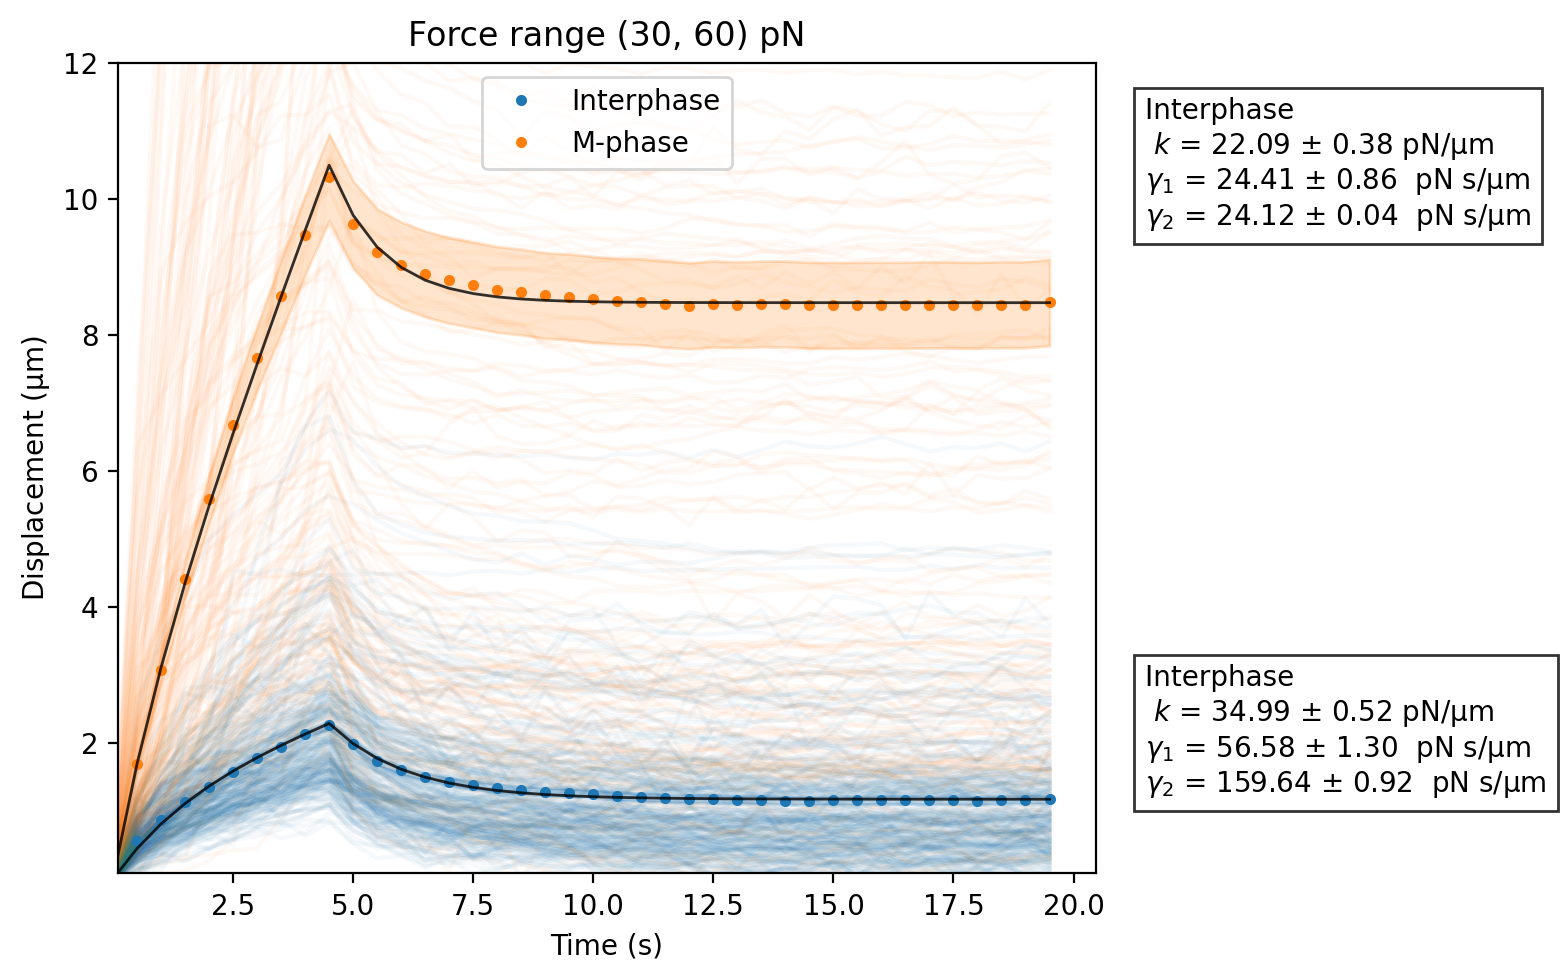

In [71]:
# all tracks 

df_all_tracks = df_all_tracks.sort_values(by=['TRACK_ID', 'NORMALIZED_TIME'], ascending=True)

for force_range in force_ranges:
    df_force_range = df_all_tracks[(df_all_tracks['AVG_FORCE']>=force_range[0])&(df_all_tracks['AVG_FORCE']<force_range[1])&(df_all_tracks['USABLE']==1)]
    # group data by MT status
    df_grouped_mean = df_force_range.groupby(by=['MT_STATUS', 'NORMALIZED_TIME']).mean(numeric_only=True).reset_index()
    df_grouped_std = df_force_range.groupby(by=['MT_STATUS', 'NORMALIZED_TIME']).sem(numeric_only=True).reset_index()
    df_grouped_mean.to_csv(f'{dir_plots}/results/results_displacement_curve_averaged_force_range{force_range[0]}-{force_range[1]}pN_{subtr_bck_label}.csv', index=False)

    plt.figure(figsize=(8, 5), dpi=200)
    for (mt_status, label, i) in zip(['y', 'n'], ['Interphase', 'M-phase'], [0, 1]):
        time_grouped = df_grouped_mean.loc[df_grouped_mean['MT_STATUS']==mt_status, 'NORMALIZED_TIME'].values

        if len(time_grouped) == 0:
            continue
        displacement_grouped = df_grouped_mean.loc[df_grouped_mean['MT_STATUS']==mt_status, displacement_column].values
        displacement_grouped_std = df_grouped_std.loc[df_grouped_std['MT_STATUS']==mt_status, displacement_column].values
        average_force_grouped = np.average(df_grouped_mean.loc[(df_grouped_mean['MT_STATUS']==mt_status)&(df_grouped_mean['MAGNET_STATUS']==1), 'FORCE [pN]'].values)
        plt.plot(time_grouped, displacement_grouped, '.', color=sns.color_palette()[i], label= label)

        plt.fill_between(
        time_grouped,
        displacement_grouped - displacement_grouped_std, 
        displacement_grouped + displacement_grouped_std,
        color=sns.color_palette()[i], alpha=0.2)

        ##### fit ######
        t_1 = time_grouped[np.argmax(displacement_grouped)]
        x_fit = np.linspace(0, np.max(time_grouped), len(time_grouped))

        sigma = np.ones(len(time_grouped))
        if creep_only:
            sigma[np.argmax(displacement_grouped):] = np.ones(len(time_grouped)-np.argmax(displacement_grouped))*np.inf
        
        yfit, popt, pcov = get_fit_jeff_full(x_fit, time_grouped, displacement_grouped,
                        np.average(df_grouped_mean.loc[(df_grouped_mean['MT_STATUS']==mt_status)&(df_grouped_mean['MAGNET_STATUS']==1), 'FORCE [pN]'].values), t_1, sigma=sigma)
        
        plt.plot(x_fit, yfit, 'k-', linewidth=1, alpha=0.8, zorder=10)

        plt.text(1.05, 0.1 + 0.7*i, f'Interphase \n $k$ = {popt[0]:.2f} $\\pm$ {np.sqrt(pcov[0][0]):.2f} pN/$\\mathrm{{\\mu m}}$\n$\\gamma_1$ = {popt[1]:.2f} $\\pm$ {np.sqrt(pcov[1][1]):.2f}  pN s/$\\mathrm{{\\mu m}}$\n$\\gamma_2$ = {popt[2]:.2f} $\\pm$ {np.sqrt(pcov[2][2]):.2f}  pN s/$\\mathrm{{\\mu m}}$', transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))


        ###############

        # plot all tracks 

        for file in df_force_range['file'].unique():
            for track in df_force_range[df_force_range['file']==file]['TRACK_ID'].unique():
                for pulse in df_force_range[(df_force_range['file']==file)&(df_force_range['TRACK_ID']==track)]['PULSE_NUMBER'].unique():
                    df = df_force_range[(df_force_range['file']==file)&(df_force_range['TRACK_ID']==track)&(df_force_range['PULSE_NUMBER']==pulse)]
                    df = df.sort_values(by='NORMALIZED_TIME', ascending=True)
                    if df['MT_STATUS'].unique() == 'y':
                        plt.plot(df['NORMALIZED_TIME'], df[displacement_column], '-', color=sns.color_palette()[0], alpha=0.02, zorder=1)
                    elif df['MT_STATUS'].unique() == 'n':
                        plt.plot(df['NORMALIZED_TIME'], df[displacement_column], '-', color=sns.color_palette()[1], alpha=0.02, zorder=1)

    plt.xlabel('Time (s)')
    plt.ylabel('Displacement ($\\mathrm{\\mu}$m)')
    plt.title(f'Force range {force_range} pN')
    plt.legend()
    plt.ylim(bottom=0, top=12)
    plt.xlim(left=0)
    # plt.yscale('log')
    # plt.xscale('log')
    plt.ylim(bottom=0.08)
    plt.xlim(left=0.1)
    plt.tight_layout()
    plt.savefig(f'{dir_plots}/results/result_displacement_curve_averaged_{subtr_bck_label}{creep_only_label}.svg', format='svg')
    plt.show()

Fit failed for embryo 20240621s01p01, MT status y in force range 30-60 pN


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:71: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results_from_averaged_tracks = pd.concat([df_results_from_averaged_tracks, pd.DataFrame(new_line, index=[0])], ignore_index=True)
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if df['MT_STATUS'].unique() == 'y':
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:82: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in futur

Fit failed for embryo 20240621s01p01, MT status n in force range 30-60 pN


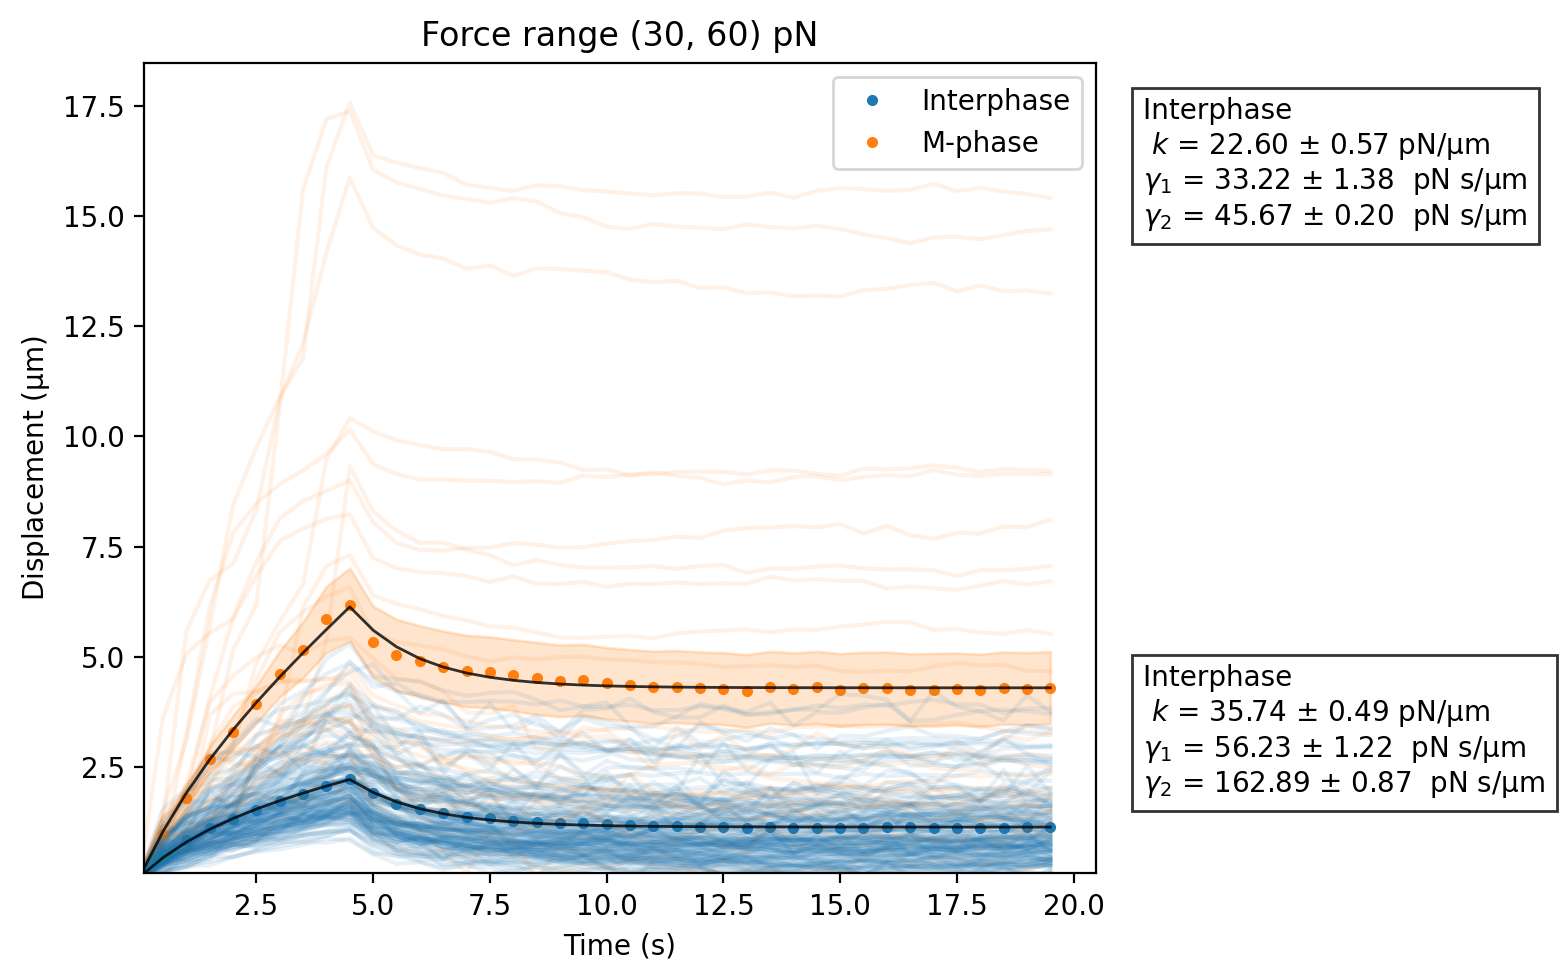

Fit failed for embryo 20240621s02p01, MT status n in force range 30-60 pN


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if df['MT_STATUS'].unique() == 'y':
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:82: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif df['MT_STATUS'].unique() == 'n':


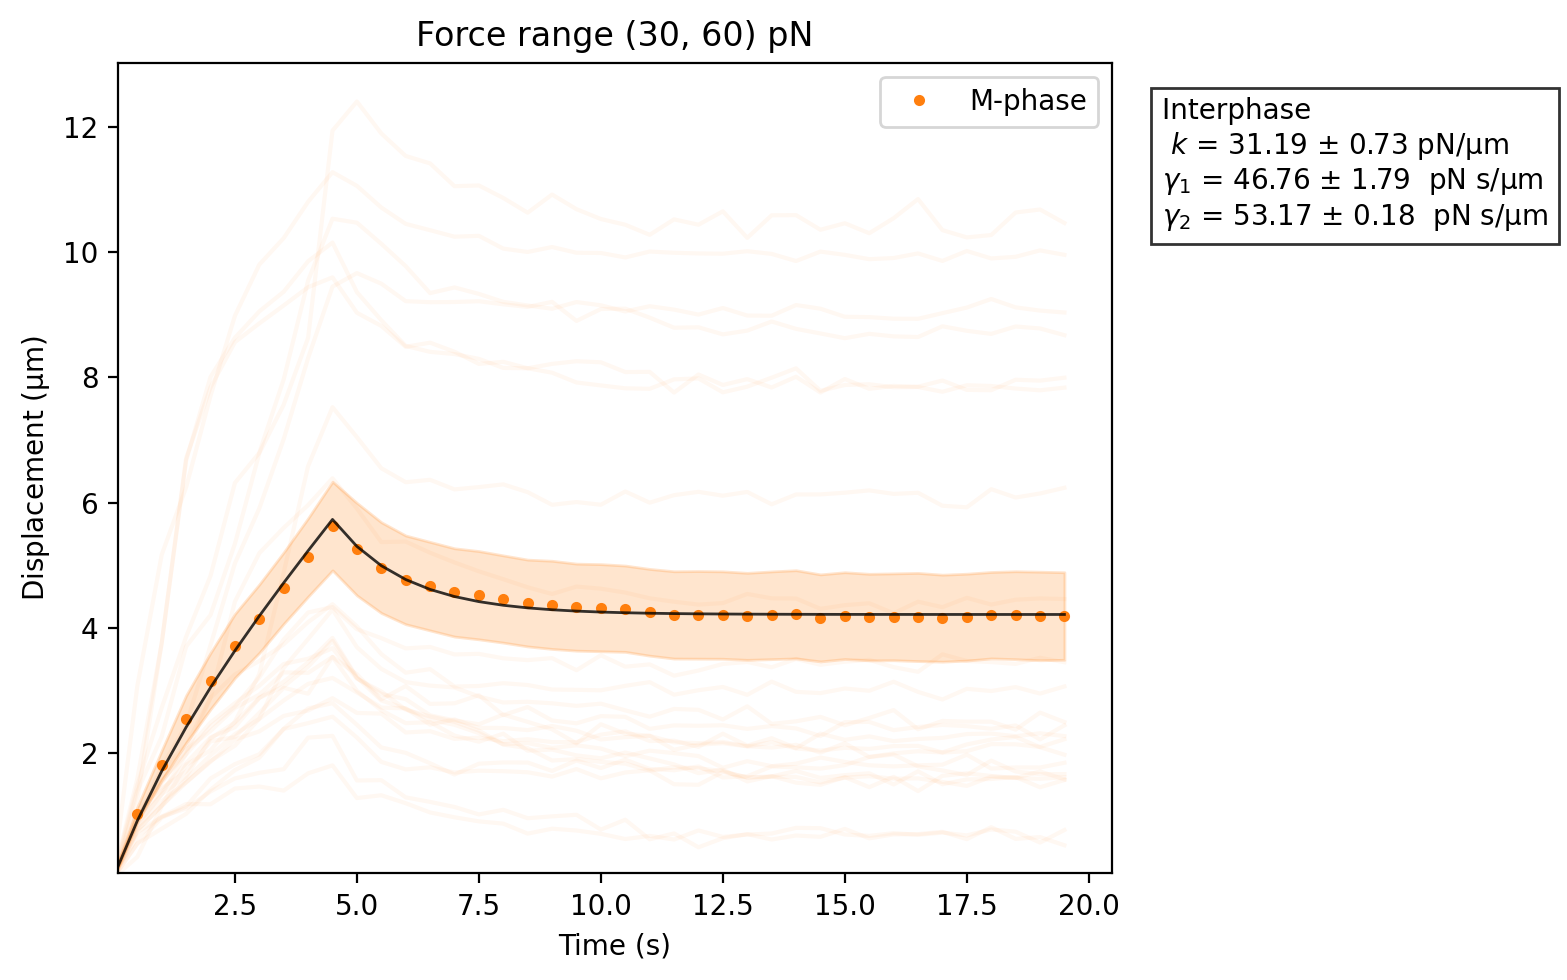

Fit failed for embryo 20240614s02p02, MT status y in force range 30-60 pN


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if df['MT_STATUS'].unique() == 'y':
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:82: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif df['MT_STATUS'].unique() == 'n':


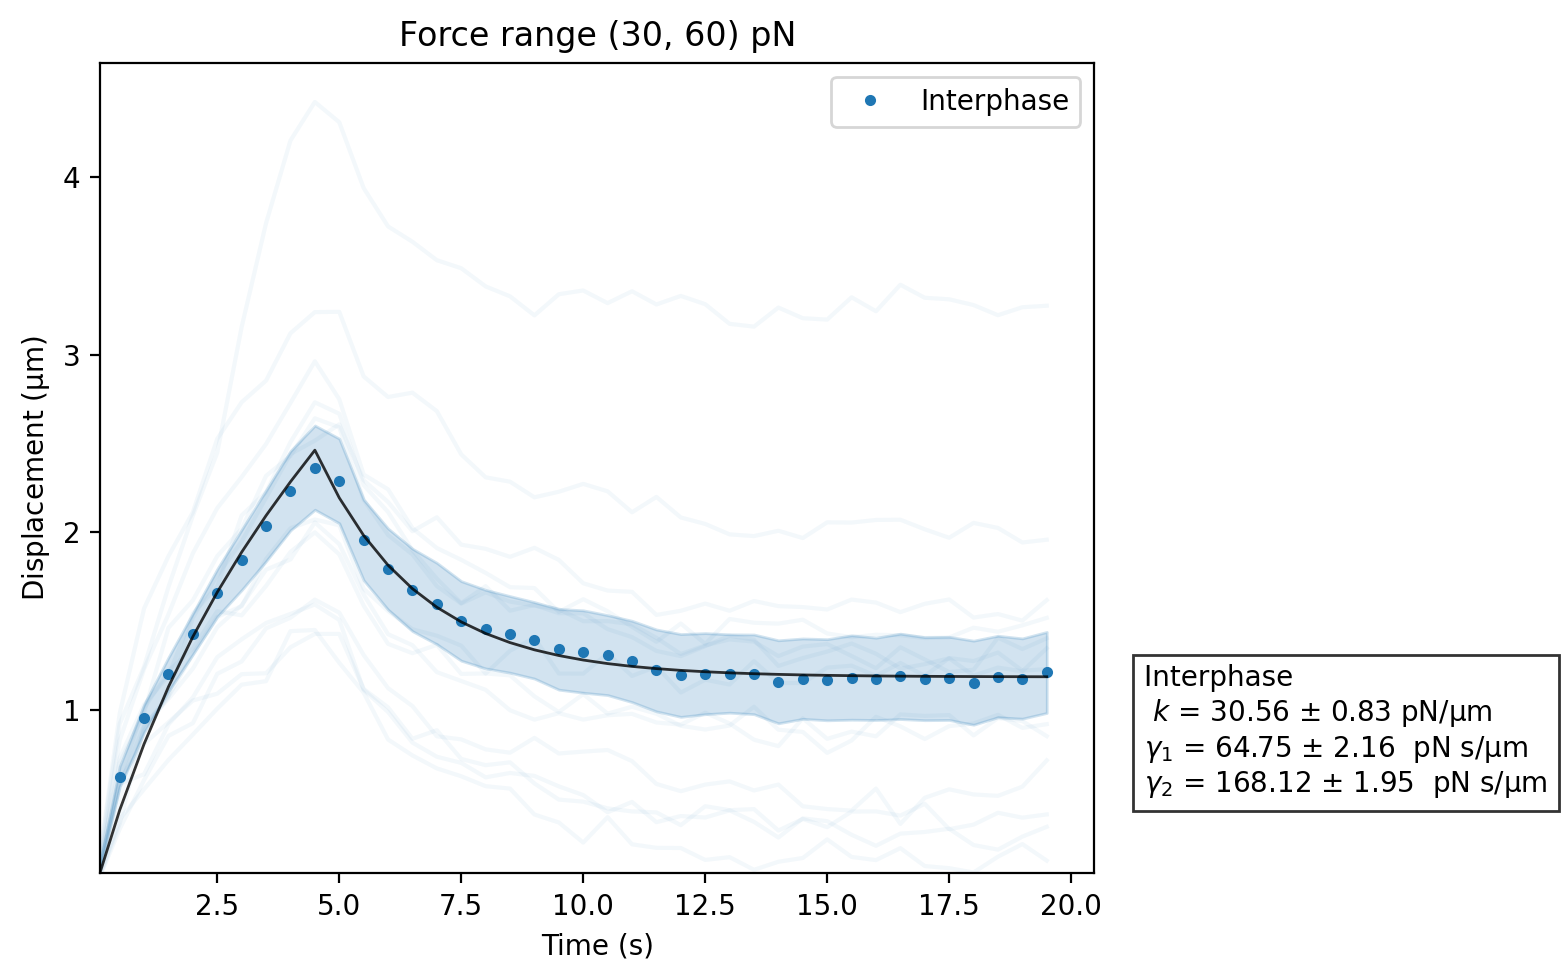

Fit failed for embryo 20240703s03p01, MT status n in force range 30-60 pN


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if df['MT_STATUS'].unique() == 'y':
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:82: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif df['MT_STATUS'].unique() == 'n':


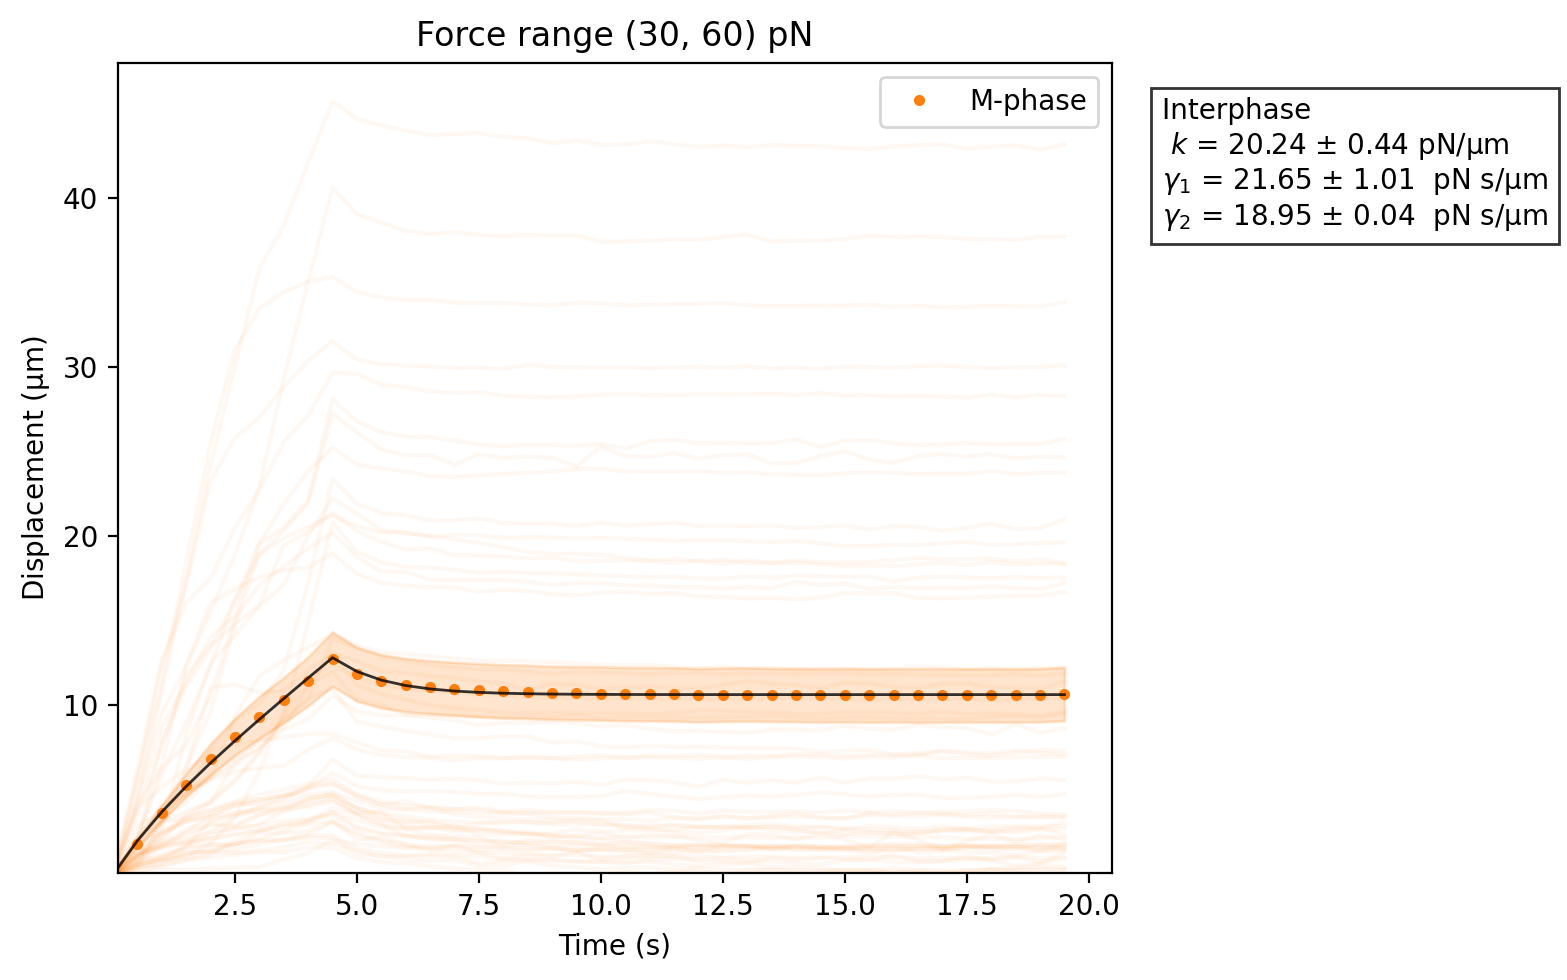

Fit failed for embryo 20240621s02p02, MT status y in force range 30-60 pN


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if df['MT_STATUS'].unique() == 'y':
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:82: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif df['MT_STATUS'].unique() == 'n':


Fit failed for embryo 20240621s02p02, MT status n in force range 30-60 pN


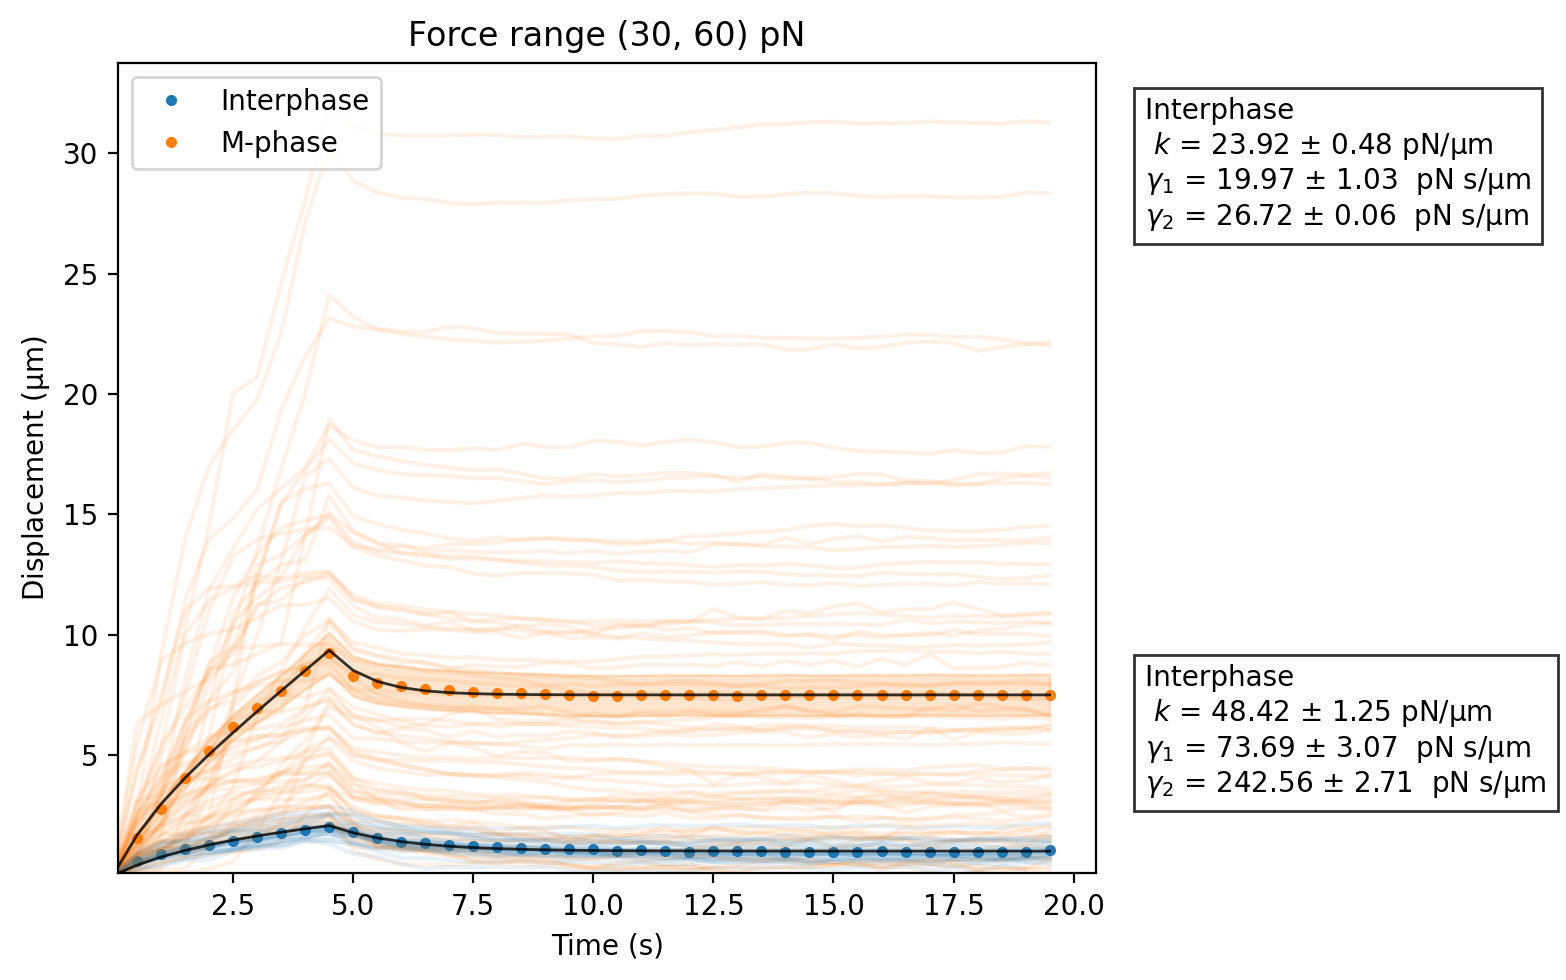

Fit failed for embryo 20240523s02p01, MT status y in force range 30-60 pN


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if df['MT_STATUS'].unique() == 'y':
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:82: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif df['MT_STATUS'].unique() == 'n':


Fit failed for embryo 20240523s02p01, MT status n in force range 30-60 pN


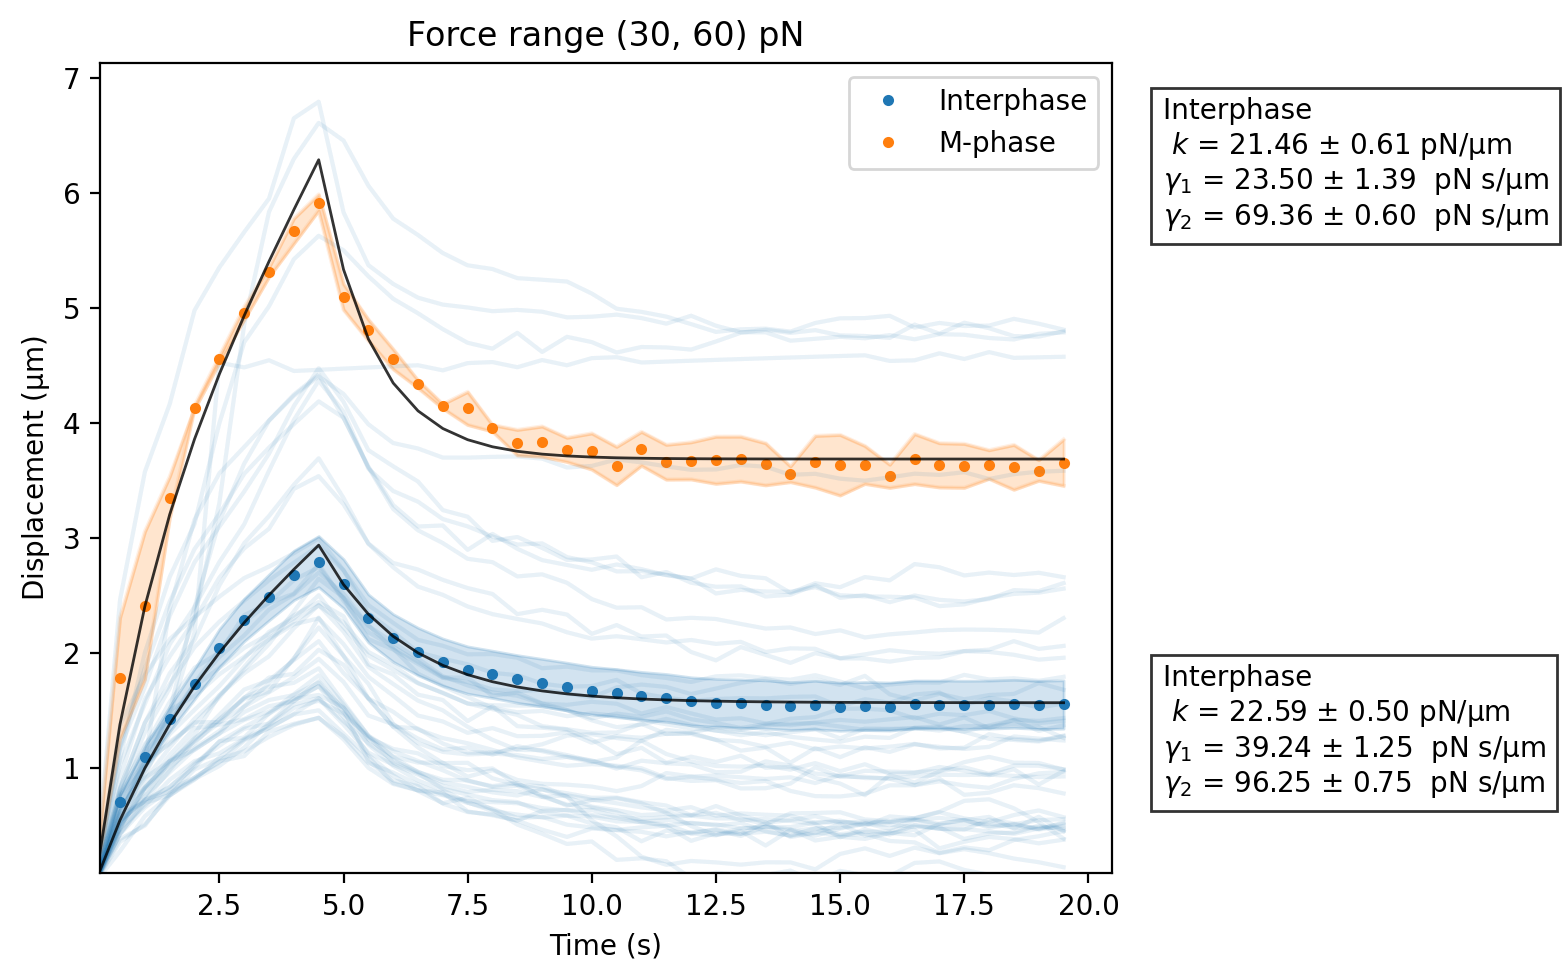

Fit failed for embryo 20240703s02p01, MT status n in force range 30-60 pN


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if df['MT_STATUS'].unique() == 'y':
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:82: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif df['MT_STATUS'].unique() == 'n':


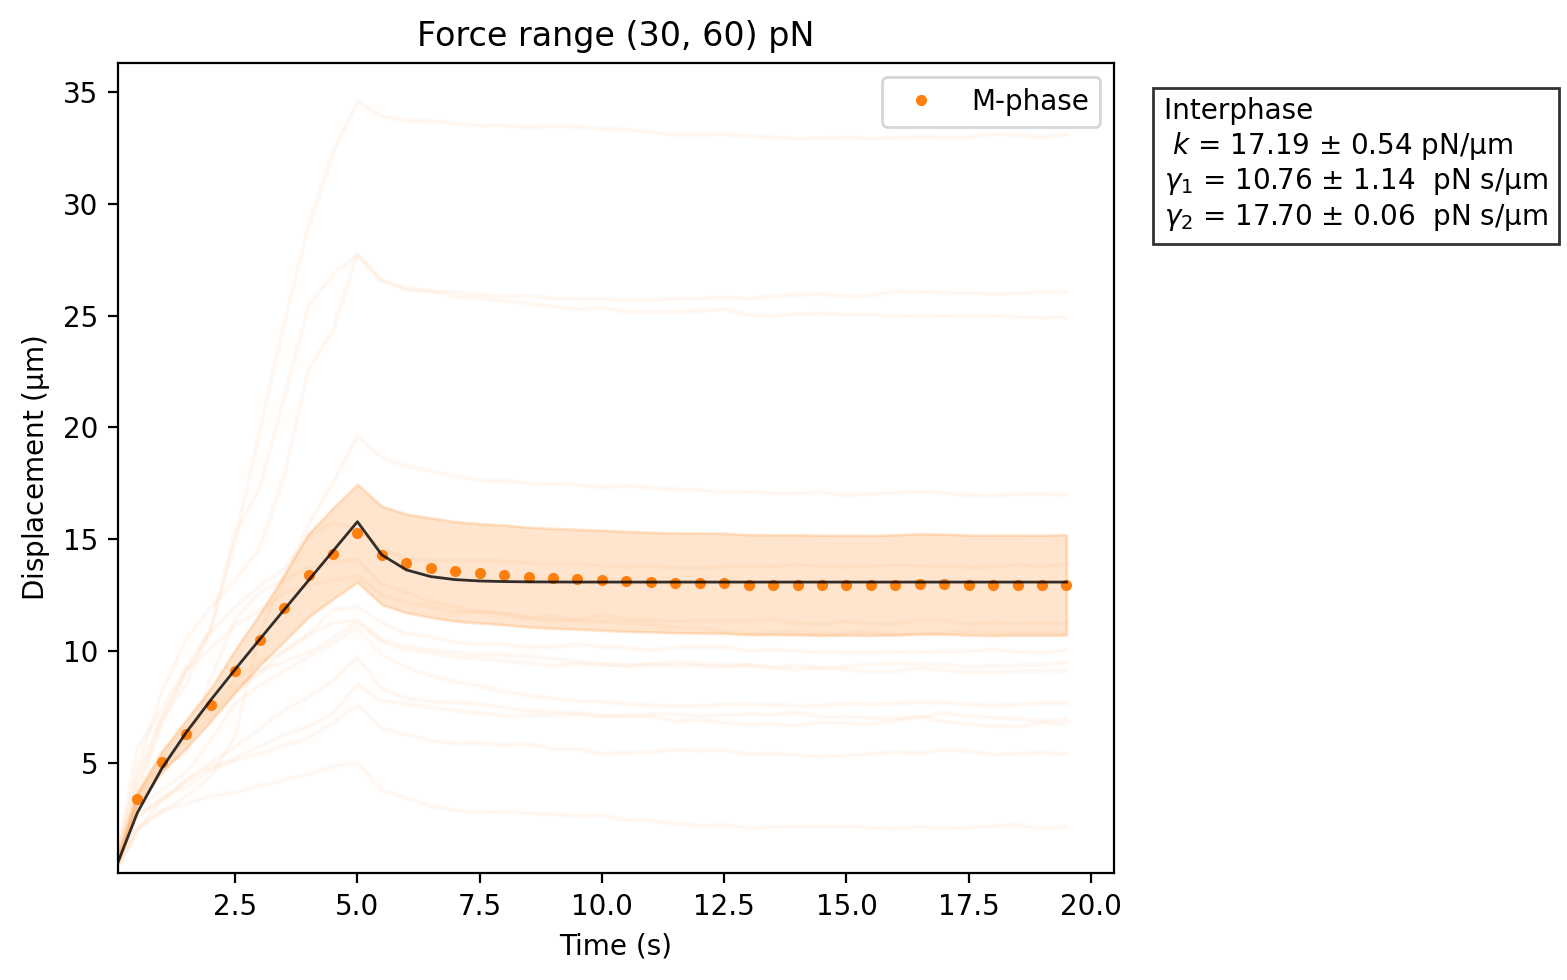

Fit failed for embryo 20240711s01p01, MT status y in force range 30-60 pN


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if df['MT_STATUS'].unique() == 'y':
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:82: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif df['MT_STATUS'].unique() == 'n':


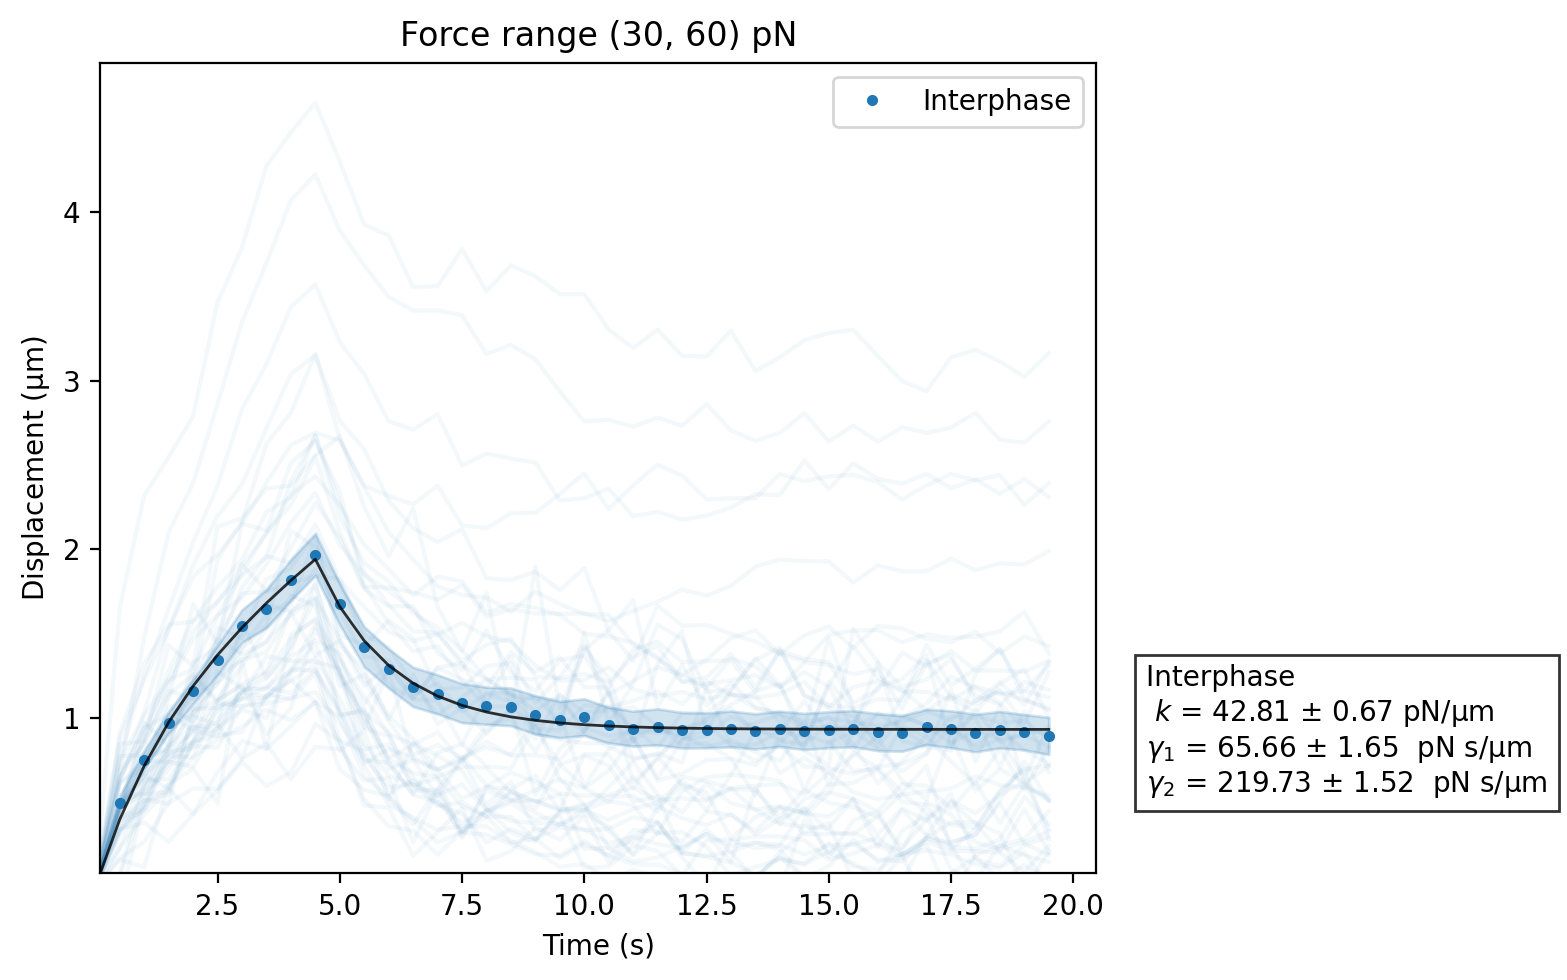

Fit failed for embryo 20240705s03p01, MT status n in force range 30-60 pN


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if df['MT_STATUS'].unique() == 'y':
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:82: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif df['MT_STATUS'].unique() == 'n':


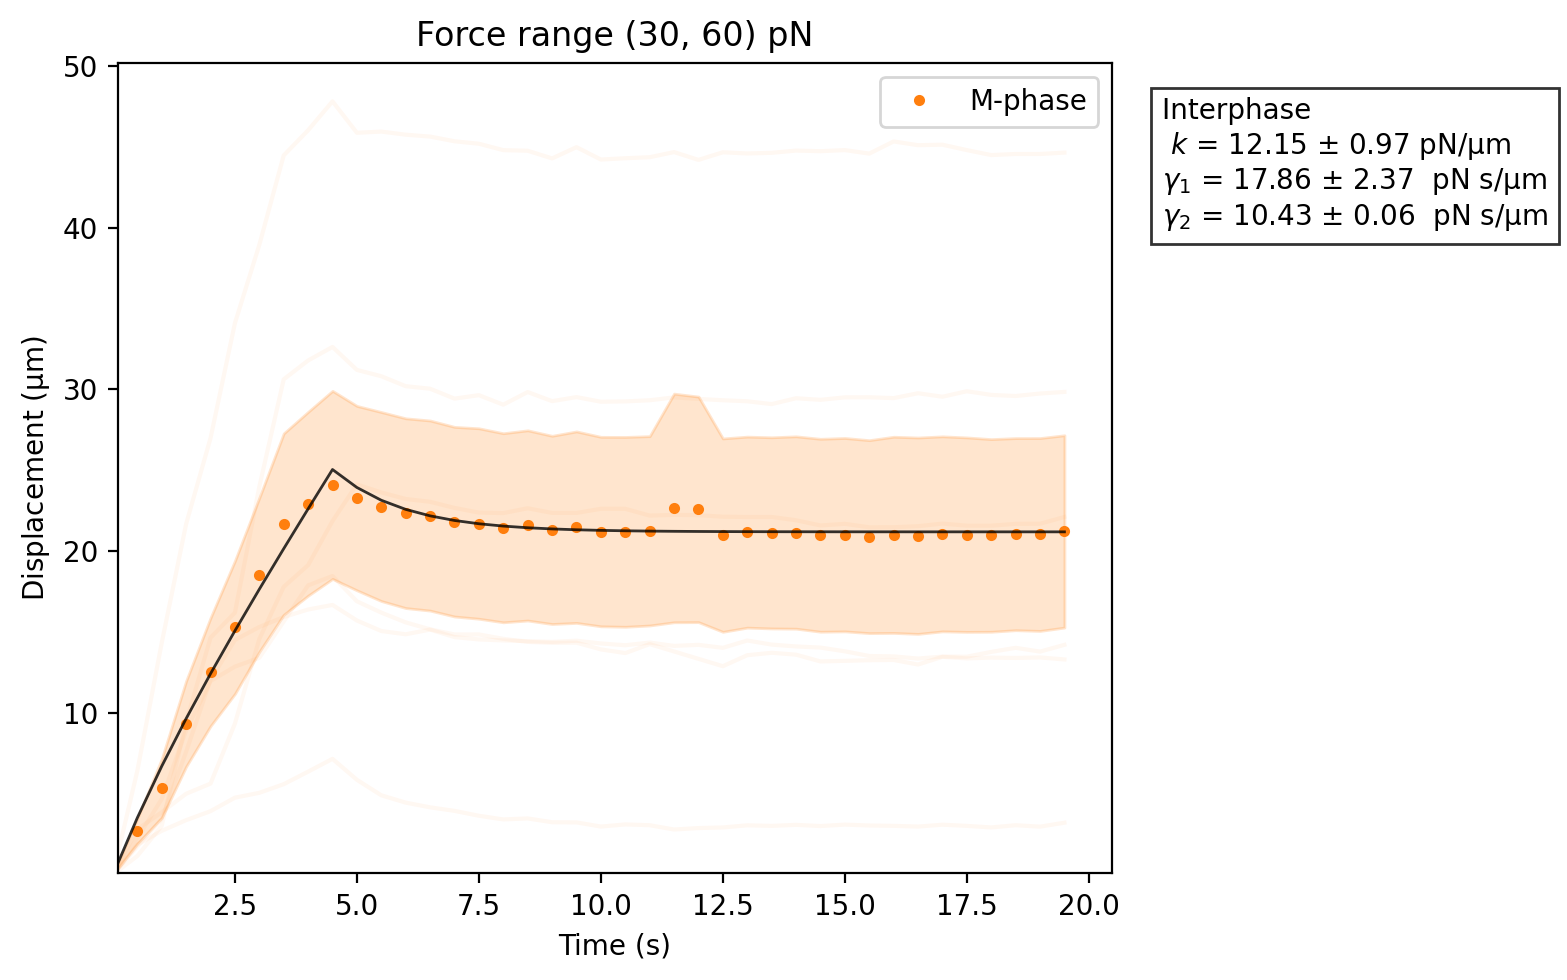

Fit failed for embryo 20240705s02p01, MT status y in force range 30-60 pN


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if df['MT_STATUS'].unique() == 'y':
/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_71139/1284255626.py:82: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif df['MT_STATUS'].unique() == 'n':


Fit failed for embryo 20240705s02p01, MT status n in force range 30-60 pN


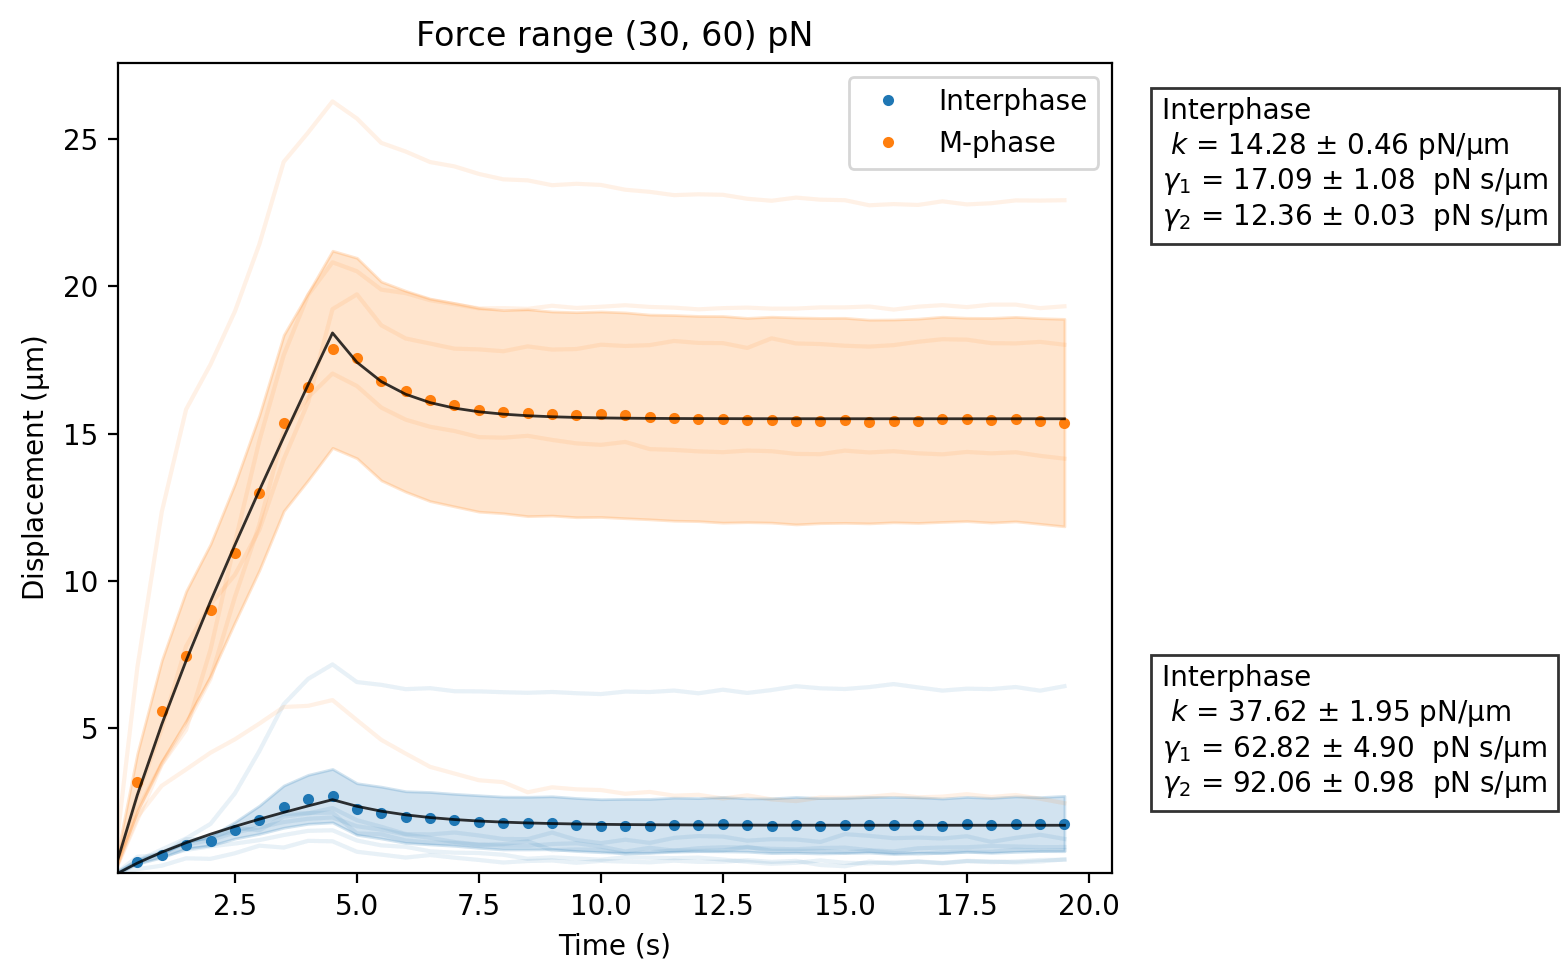

In [ ]:
df_all_tracks = df_all_tracks.sort_values(by=['TRACK_ID', 'NORMALIZED_TIME'], ascending=True)

df_results_from_averaged_tracks = pd.DataFrame(columns=['EMBRYO', 'MT_STATUS', 'AVG_FORCE'])

for force_range in force_ranges:
    df_force_range = df_all_tracks[(df_all_tracks['AVG_FORCE']>=force_range[0])&(df_all_tracks['AVG_FORCE']<force_range[1])&(df_all_tracks['USABLE']==1)]
    
    for embryo in df_force_range['EMBRYO'].unique():
        # group data by MT status
        df_grouped_mean = df_force_range[df_force_range['EMBRYO']==embryo].groupby(by=['MT_STATUS', 'NORMALIZED_TIME']).mean(numeric_only=True).reset_index()
        df_grouped_std = df_force_range[df_force_range['EMBRYO']==embryo].groupby(by=['MT_STATUS', 'NORMALIZED_TIME']).sem(numeric_only=True).reset_index()
        # df_grouped_mean.to_csv(f'{dir_plots}/results/results_displacement_curve_averaged_force_range{force_range[0]}-{force_range[1]}pN_{subtr_bck_label}.csv', index=False)

        plt.figure(figsize=(8, 5), dpi=200)
        for (mt_status, label, i) in zip(['y', 'n'], ['Interphase', 'M-phase'], [0, 1]):
            time_grouped = df_grouped_mean.loc[df_grouped_mean['MT_STATUS']==mt_status, 'NORMALIZED_TIME'].values

            if len(time_grouped) == 0:
                continue
            displacement_grouped = df_grouped_mean.loc[df_grouped_mean['MT_STATUS']==mt_status, displacement_column].values
            displacement_grouped_std = df_grouped_std.loc[df_grouped_std['MT_STATUS']==mt_status, displacement_column].values
            average_force_grouped = np.average(df_grouped_mean.loc[(df_grouped_mean['MT_STATUS']==mt_status)&(df_grouped_mean['MAGNET_STATUS']==1), 'FORCE [pN]'].values)
            plt.plot(time_grouped, displacement_grouped, '.', color=sns.color_palette()[i], label= label)

            plt.fill_between(
            time_grouped,
            displacement_grouped - displacement_grouped_std, 
            displacement_grouped + displacement_grouped_std,
            color=sns.color_palette()[i], alpha=0.2)

            ##### fit ######
            t_1 = time_grouped[np.argmax(displacement_grouped)]
            x_fit = np.linspace(0, np.max(time_grouped), len(time_grouped))

            sigma = np.ones(len(time_grouped))
            if creep_only:
                sigma[np.argmax(displacement_grouped):] = np.ones(len(time_grouped)-np.argmax(displacement_grouped))*np.inf
            
            yfit, popt, pcov = get_fit_jeff_full(x_fit, time_grouped, displacement_grouped,
                            np.average(df_grouped_mean.loc[(df_grouped_mean['MT_STATUS']==mt_status)&(df_grouped_mean['MAGNET_STATUS']==1), 'FORCE [pN]'].values), t_1, sigma=sigma)
            
            plt.plot(x_fit, yfit, 'k-', linewidth=1, alpha=0.8, zorder=10)

            plt.text(1.05, 0.1 + 0.7*i, f'Interphase \n $k$ = {popt[0]:.2f} $\\pm$ {np.sqrt(pcov[0][0]):.2f} pN/$\\mathrm{{\\mu m}}$\n$\\gamma_1$ = {popt[1]:.2f} $\\pm$ {np.sqrt(pcov[1][1]):.2f}  pN s/$\\mathrm{{\\mu m}}$\n$\\gamma_2$ = {popt[2]:.2f} $\\pm$ {np.sqrt(pcov[2][2]):.2f}  pN s/$\\mathrm{{\\mu m}}$', transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
        

            print(f'Fit failed for embryo {embryo}, MT status {mt_status} in force range {force_range[0]}-{force_range[1]} pN')

            ###############
            
            # include model independent analysis
            # calculate R squared
            R_sq = r_squared(displacement_grouped, yfit)
            new_line = { 'EMBRYO': embryo,
                        'MT_STATUS': mt_status, 
                        'AVG_FORCE': average_force_grouped,
                        'k': popt[0], 
                        'eta_1': popt[1], 
                        'eta_2': popt[2], 
                        'k_err': np.sqrt(pcov[0][0]), 
                        'eta_1_err': np.sqrt(pcov[1][1]), 
                        'eta_2_err': np.sqrt(pcov[2][2]),
                        't_1': t_1,
                        'R_SQUARED': R_sq, 
                        'rising_dif': [np.max(displacement_grouped)], 
                        'relaxing_dif': [np.max(displacement_grouped) - displacement_grouped[-1]], 
                        'rising_dif_norm': [np.max(displacement_grouped)/average_force_grouped], 
                        'relative_dif': [(np.max(displacement_grouped) - displacement_grouped[-1])/ np.max(displacement_grouped)]
                        }

            df_results_from_averaged_tracks = pd.concat([df_results_from_averaged_tracks, pd.DataFrame(new_line, index=[0])], ignore_index=True)

            # plot all tracks 

            for file in df_force_range['file'].unique():
                for track in df_force_range[df_force_range['file']==file]['TRACK_ID'].unique():
                    for pulse in df_force_range[(df_force_range['file']==file)&(df_force_range['TRACK_ID']==track)]['PULSE_NUMBER'].unique():
                        df = df_force_range[(df_force_range['EMBRYO']==embryo)&(df_force_range['file']==file)&(df_force_range['TRACK_ID']==track)&(df_force_range['PULSE_NUMBER']==pulse)]
                        df = df.sort_values(by='NORMALIZED_TIME', ascending=True)
                        if df['MT_STATUS'].unique() == 'y':
                            plt.plot(df['NORMALIZED_TIME'], df[displacement_column], '-', color=sns.color_palette()[0], alpha=0.05)
                        elif df['MT_STATUS'].unique() == 'n':
                            plt.plot(df['NORMALIZED_TIME'], df[displacement_column], '-', color=sns.color_palette()[1], alpha=0.05)

        plt.xlabel('Time (s)')
        plt.ylabel('Displacement ($\\mathrm{\\mu}$m)')
        plt.title(f'Force range {force_range} pN')
        plt.legend()
        # plt.ylim(bottom=0, top=12)
        plt.xlim(left=0)
        # plt.yscale('log')
        # plt.xscale('log')
        plt.ylim(bottom=0.08)
        plt.xlim(left=0.1)
        plt.tight_layout()
        plt.savefig(f'{dir_plots}/results/averaged_curves_per_embryo/result_displacement_curve_averaged_{embryo}_{subtr_bck_label}{creep_only_label}.svg', format='svg')
        plt.show()

In [73]:
df_results_from_averaged_tracks.to_csv(f'{dir_plots}/results/results_displacement_curve_averaged_force_range{force_range[0]}-{force_range[1]}pN_{subtr_bck_label}{creep_only_label}.csv', index=False)
df_results_from_averaged_tracks.head()

,EMBRYO,MT_STATUS,AVG_FORCE,k,eta_1,eta_2,k_err,eta_1_err,eta_2_err,t_1,R_SQUARED,rising_dif,relaxing_dif,rising_dif_norm,relative_dif
0,20240621s01p01,y,40.983104,35.743618,56.229094,162.888022,0.489479,1.215626,0.871460,4.5,0.995323,2.214751,1.085540,0.054041,0.490141
1,20240621s01p01,n,43.575564,22.602714,33.224930,45.667791,0.565135,1.384504,0.201904,4.5,0.994469,6.182154,1.881482,0.141872,0.304341
2,20240621s02p01,n,49.791153,31.189392,46.763753,53.171054,0.728654,1.792398,0.184239,4.5,0.996298,5.626224,1.437010,0.112996,0.255413
3,20240614s02p02,y,44.317979,30.562277,64.753002,168.120738,0.833032,2.159971,1.951887,4.5,0.985146,2.364753,1.153152,0.053359,0.487642
4,20240703s03p01,n,44.820685,20.243383,21.645545,18.953624,0.442599,1.008148,0.036912,4.5,0.998652,12.735317,2.059005,0.284139,0.161677
